In [5]:
import os
import pandas as pd

def prepare_and_save_dataset(data_dir=os.path.join('..', 'data'), input_file='data.csv', output_file='emotify_clean.csv', threshold=0.40):
    """
    Cleans the dataset, aggregates user ratings by track ID, and creates 
    file paths for the audio samples.
    """
    # Construct full paths relative to the project root
    input_path = os.path.join(data_dir, input_file)
    output_path = os.path.join(data_dir, output_file)
    audio_base_folder = os.path.join(data_dir, "Emotify_Audio")
    
    print(f"Loading dataset from {input_path}...")
    df = pd.read_csv(input_path)
    df.columns = df.columns.str.strip()
    
    emotion_labels = [
        'amazement', 'solemnity', 'tenderness', 'nostalgia', 'calmness', 
        'power', 'joyful_activation', 'tension', 'sadness'
    ]
    
    print(f"Grouping ratings by track ID (from {len(df)} initial records)...")
    df_grouped = df.groupby('track id').agg({
        'genre': 'first',
        **{emotion: 'mean' for emotion in emotion_labels}
    }).reset_index()
    
    # Apply binary thresholding for multi-label classification
    print(f"Applying threshold (threshold = {threshold})...")
    for col in emotion_labels:
        df_grouped[col] = (df_grouped[col] >= threshold).astype(int)
        
    # Assign local_id (1-100) per genre
    df_grouped['local_id'] = df_grouped.groupby('genre')['track id'].rank(method='first').astype(int)
    
    # Construct file paths
    df_grouped['file_path'] = df_grouped.apply(
        lambda row: f"Emotify_Audio/{row['genre']}/{row['local_id']}.mp3", 
        axis=1
    )
    
    # Verify file existence
    missing_files = 0
    for path in df_grouped['file_path']:
        full_path = os.path.join(data_dir, path)
        if not os.path.exists(full_path):
            missing_files += 1
            if missing_files <= 3:
                print(f"Warning: File not found: {full_path}")

    if missing_files > 0:
        print(f"\nALERT: {missing_files} files missing! Check folder structure.")
    else:
        print("\nSUCCESS: All 400 audio files verified!")
        
    df_grouped.to_csv(output_path, index=False)
    print(f"Clean dataset saved to: {output_path}")
    return df_grouped

# Execute
if __name__ == "__main__":
    clean_dataset = prepare_and_save_dataset(threshold=0.40)
    print("\nVerification for 'rock' genre:")
    print(clean_dataset[clean_dataset['genre'] == 'rock'][['track id', 'genre', 'local_id', 'file_path']].head())

Loading dataset from ..\data\data.csv...
Grouping ratings by track ID (from 8407 initial records)...
Applying threshold (threshold = 0.4)...

SUCCESS: All 400 audio files verified!
Clean dataset saved to: ..\data\emotify_clean.csv

Verification for 'rock' genre:
     track id genre  local_id                 file_path
100       101  rock         1  Emotify_Audio/rock/1.mp3
101       102  rock         2  Emotify_Audio/rock/2.mp3
102       103  rock         3  Emotify_Audio/rock/3.mp3
103       104  rock         4  Emotify_Audio/rock/4.mp3
104       105  rock         5  Emotify_Audio/rock/5.mp3


4 Labels

In [8]:
import os
import pandas as pd
import numpy as np

def prepare_and_save_less_labels(data_dir=os.path.join('..', 'data'), input_file='data.csv', output_file='emotify_lesslabels.csv', threshold=0.40):
    """
    Groups the 9 GEMS-9 emotional labels into 4 broader categories (Valence-Arousal axes)
    and generates the final dataset for CRNN training.
    """
    input_path = os.path.join(data_dir, input_file)
    output_path = os.path.join(data_dir, output_file)
    
    print("Loading initial dataset...")
    df = pd.read_csv(input_path)
    df.columns = df.columns.str.strip()
    
    original_emotions = [
        'amazement', 'solemnity', 'tenderness', 'nostalgia', 'calmness', 
        'power', 'joyful_activation', 'tension', 'sadness'
    ]
    
    # 1. Aggregate ratings by track ID
    print("Aggregating ratings and calculating means per track...")
    df_grouped = df.groupby('track id').agg({
        'genre': 'first',
        **{emotion: 'mean' for emotion in original_emotions}
    }).reset_index()
    
    # 2. Binary thresholding for multi-label classification
    print(f"Applying threshold (threshold = {threshold})...")
    for col in original_emotions:
        df_grouped[col] = (df_grouped[col] >= threshold).astype(int)
        
    # 3. Label mapping to 4 broader emotional categories
    print("Mapping labels to 4 primary emotional axes...")
    df_grouped['energy_joy'] = df_grouped[['amazement', 'power', 'joyful_activation']].max(axis=1)
    df_grouped['calm_relax'] = df_grouped[['tenderness', 'calmness']].max(axis=1)
    df_grouped['sadness_nostalgia'] = df_grouped[['solemnity', 'nostalgia', 'sadness']].max(axis=1)
    df_grouped['tension_fear'] = df_grouped['tension']
    
    # 4. Generate file paths for audio samples
    df_grouped['local_id'] = df_grouped.groupby('genre')['track id'].rank(method='first').astype(int)
    df_grouped['file_path'] = df_grouped.apply(
        lambda row: f"Emotify_Audio/{row['genre']}/{row['local_id']}.mp3", 
        axis=1
    )
    
    # 5. Final column selection and validation
    final_cols = ['track id', 'genre', 'file_path', 'energy_joy', 'calm_relax', 'sadness_nostalgia', 'tension_fear']
    df_final = df_grouped[final_cols]
    
    missing_files = sum(1 for path in df_final['file_path'] if not os.path.exists(os.path.join(data_dir, path)))
    
    if missing_files == 0:
        print("SUCCESS: All audio files verified.")
    else:
        print(f"WARNING: {missing_files} files are missing. Check directory structure.")

    df_final.to_csv(output_path, index=False)
    print(f"\nDataset saved successfully to: {output_path}")
    
    # Summary of distribution
    print("\nSample distribution per category:")
    for col in ['energy_joy', 'calm_relax', 'sadness_nostalgia', 'tension_fear']:
        print(f"- {col}: {df_final[col].sum()} tracks")
        
    return df_final

# Execute
if __name__ == "__main__":
    new_dataset = prepare_and_save_less_labels(threshold=0.40)

Loading initial dataset...
Aggregating ratings and calculating means per track...
Applying threshold (threshold = 0.4)...
Mapping labels to 4 primary emotional axes...
SUCCESS: All audio files verified.

Dataset saved successfully to: ..\data\emotify_lesslabels.csv

Sample distribution per category:
- energy_joy: 145 tracks
- calm_relax: 157 tracks
- sadness_nostalgia: 150 tracks
- tension_fear: 78 tracks


In [9]:
import os
import pandas as pd
import librosa

def profile_audio_dataset(data_dir=os.path.join('..', 'data'), csv_file='emotify_clean.csv', num_samples=3):
    """
    Analyzes a sample of audio files to verify properties such as duration,
    sample rate, and channels, ensuring consistency for the CRNN pipeline.
    """
    csv_path = os.path.join(data_dir, csv_file)
    df = pd.read_csv(csv_path)
    
    # Randomly sample files to check data integrity
    sample_files = df['file_path'].sample(num_samples, random_state=42).tolist()
    
    print(f"=== Audio Dataset Profiling (Sample size: {num_samples}) ===")
    
    for relative_path in sample_files:
        full_path = os.path.join(data_dir, relative_path)
        
        if os.path.exists(full_path):
            # Load audio without resampling to check native properties
            y, sr = librosa.load(full_path, sr=None, mono=False)
            
            # File size in MB
            file_size_mb = os.path.getsize(full_path) / (1024 * 1024)
            
            # Duration and Channels
            duration = librosa.get_duration(y=y, sr=sr)
            channels = y.shape[0] if len(y.shape) > 1 else 1
            
            print(f"File: {relative_path}")
            print(f" ‣ Size: {file_size_mb:.2f} MB")
            print(f" ‣ Duration: {duration:.2f} seconds")
            print(f" ‣ Sample Rate: {sr} Hz")
            print(f" ‣ Channels: {'Stereo (2)' if channels == 2 else 'Mono (1)'}")
            print("-" * 50)
        else:
            print(f"Error: File not found at {full_path}")

if __name__ == "__main__":
    profile_audio_dataset()

=== Audio Dataset Profiling (Sample size: 3) ===


c:\Users\panag\Documents\metaptyxiako\ai\ergasia\venv_ai\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


File: Emotify_Audio/electronic/10.mp3
 ‣ Size: 0.92 MB
 ‣ Duration: 60.03 seconds
 ‣ Sample Rate: 44100 Hz
 ‣ Channels: Stereo (2)
--------------------------------------------------
File: Emotify_Audio/electronic/81.mp3
 ‣ Size: 0.92 MB
 ‣ Duration: 60.03 seconds
 ‣ Sample Rate: 44100 Hz
 ‣ Channels: Stereo (2)
--------------------------------------------------
File: Emotify_Audio/classical/34.mp3
 ‣ Size: 0.92 MB
 ‣ Duration: 60.03 seconds
 ‣ Sample Rate: 44100 Hz
 ‣ Channels: Stereo (2)
--------------------------------------------------


In [10]:
import os
import numpy as np
import librosa
import soundfile as sf
from tqdm import tqdm

def extract_and_crop_features(data_dir=os.path.join('..', 'data')):
    """
    Processes raw MP3 files into Log-Mel Spectrograms and saves them as .npy files.
    Applies zero-padding to ensure uniform length for the CRNN model.
    """
    source_base_dir = os.path.join(data_dir, "Emotify_Audio")
    audio_cleaned_dir = os.path.join(data_dir, "Emotify_Audio_cleaned")
    npy_target_dir = os.path.join(data_dir, "Emotify_npy")
    
    duration = 30.0
    sr = 22050
    n_mels = 128
    
    os.makedirs(audio_cleaned_dir, exist_ok=True)
    os.makedirs(npy_target_dir, exist_ok=True)
    
    print(f"Scanning source directory: {source_base_dir}...")
    
    for genre in os.listdir(source_base_dir):
        source_genre_path = os.path.join(source_base_dir, genre)
        
        if not os.path.isdir(source_genre_path):
            continue
            
        print(f"Processing genre: {genre}")
        target_audio_genre = os.path.join(audio_cleaned_dir, genre)
        target_npy_genre = os.path.join(npy_target_dir, genre)
        os.makedirs(target_audio_genre, exist_ok=True)
        os.makedirs(target_npy_genre, exist_ok=True)
        
        mp3_files = [f for f in os.listdir(source_genre_path) if f.endswith('.mp3')]
        
        for file in tqdm(mp3_files):
            source_mp3_path = os.path.join(source_genre_path, file)
            base_name = os.path.splitext(file)[0]
            
            npy_path = os.path.join(target_npy_genre, f"{base_name}.npy")
            
            if os.path.exists(npy_path):
                continue
                
            try:
                # Load audio and crop to duration
                y, _ = librosa.load(source_mp3_path, sr=sr, duration=duration)
                
                # Apply Padding if file is shorter than 30s
                expected_length = int(sr * duration)
                if len(y) < expected_length:
                    y = np.pad(y, (0, expected_length - len(y)), mode='constant')
                
                # 1. Convert to Log-Mel Spectrogram
                S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels)
                S_dB = librosa.power_to_db(S, ref=np.max)
                
                # 2. Min-Max Scaling [0, 1] for stable gradient descent
                S_norm = (S_dB - S_dB.min()) / (S_dB.max() - S_dB.min() + 1e-8)
                
                # Save as .npy
                np.save(npy_path, S_norm)
                
            except Exception as e:
                print(f"\nError processing {file}: {e}")

    print("\nFeature extraction completed successfully!")

if __name__ == "__main__":
    extract_and_crop_features()

Scanning source directory: ..\data\Emotify_Audio...
Processing genre: classical


100%|██████████| 100/100 [00:23<00:00,  4.29it/s]


Processing genre: electronic


100%|██████████| 100/100 [00:20<00:00,  4.83it/s]


Processing genre: pop


100%|██████████| 100/100 [00:21<00:00,  4.68it/s]


Processing genre: rock


100%|██████████| 100/100 [00:19<00:00,  5.04it/s]


Feature extraction completed successfully!


NEW CATALOG

In [12]:
import os
import pandas as pd

def generate_final_dataset_index(data_dir=os.path.join('..', 'data'), input_file='emotify_clean.csv', output_file='emotify_final_dataset.csv'):
    """
    Creates the final dataset index by mapping labels to the generated feature files (.npy)
    and processed audio files (.wav).
    """
    input_path = os.path.join(data_dir, input_file)
    output_path = os.path.join(data_dir, output_file)
    
    print(f"Loading clean dataset from {input_path}...")
    df = pd.read_csv(input_path)
    
    # Define directory paths
    npy_folder = "Emotify_npy"
    audio_cleaned_folder = "Emotify_Audio_cleaned"

    # Map paths to feature files and processed audio
    df['npy_path'] = df.apply(
        lambda row: os.path.join(npy_folder, row['genre'], f"{int(row['local_id'])}.npy"), 
        axis=1
    )
    df['cropped_wav_path'] = df.apply(
        lambda row: os.path.join(audio_cleaned_folder, row['genre'], f"{int(row['local_id'])}_cropped.wav"), 
        axis=1
    )

    # Validate file existence
    npy_exists = df['npy_path'].apply(lambda x: os.path.exists(os.path.join(data_dir, x))).sum()
    wav_exists = df['cropped_wav_path'].apply(lambda x: os.path.exists(os.path.join(data_dir, x))).sum()

    print(f"\nFile Validation:")
    print(f"- Found {npy_exists} / 400 .npy feature files")
    print(f"- Found {wav_exists} / 400 .wav processed audio files")

    # Export final index
    df.to_csv(output_path, index=False)
    print(f"\nSUCCESS: Final dataset index saved to: {output_file}")
    
    return df

if __name__ == "__main__":
    df_final = generate_final_dataset_index()
    print("\nDataset Preview:")
    print(df_final[['track id', 'genre', 'npy_path']].head())

Loading clean dataset from ..\data\emotify_clean.csv...

File Validation:
- Found 400 / 400 .npy feature files
- Found 0 / 400 .wav processed audio files

SUCCESS: Final dataset index saved to: emotify_final_dataset.csv

Dataset Preview:
   track id      genre                     npy_path
0         1  classical  Emotify_npy\classical\1.npy
1         2  classical  Emotify_npy\classical\2.npy
2         3  classical  Emotify_npy\classical\3.npy
3         4  classical  Emotify_npy\classical\4.npy
4         5  classical  Emotify_npy\classical\5.npy


In [ ]:
print(df_final.head())

NPY IMAGE

Spectrogram dimensions (Mel-bands, Time-steps): (128, 1292)


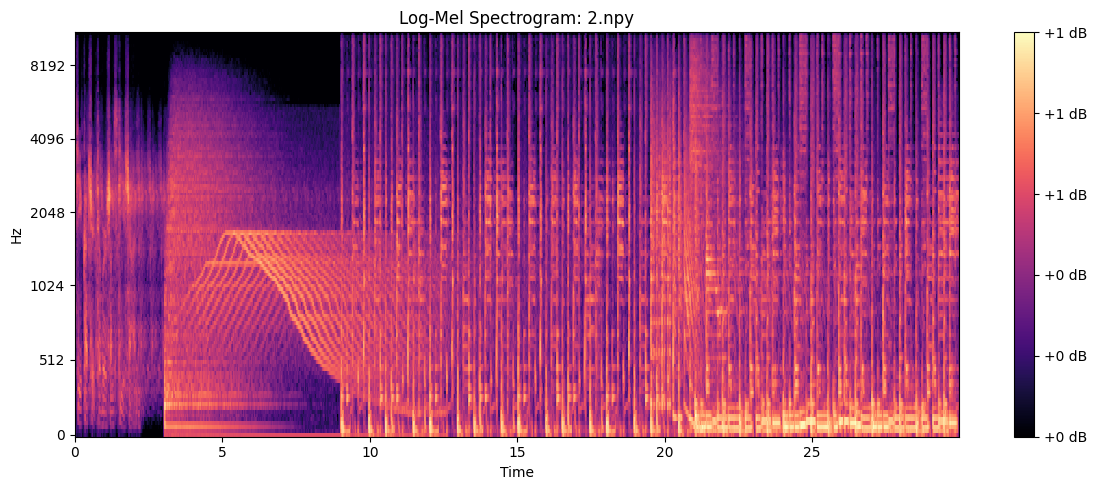

In [15]:
import os
import numpy as np
import matplotlib.pyplot as plt
import librosa.display

def visualize_spectrogram(npy_file_path, sr=22050):
    """
    Visualizes a saved Mel-Spectrogram .npy file.
    Helps in validating feature extraction before CRNN training.
    """
    if not os.path.exists(npy_file_path):
        print(f"Error: File {npy_file_path} not found.")
        return

    # Load the spectrogram data
    data = np.load(npy_file_path)
    print(f"Spectrogram dimensions (Mel-bands, Time-steps): {data.shape}")

    # Plotting
    plt.figure(figsize=(12, 5))
    librosa.display.specshow(data, x_axis='time', y_axis='mel', sr=sr)
    plt.colorbar(format='%+2.0f dB')
    plt.title(f"Log-Mel Spectrogram: {os.path.basename(npy_file_path)}")
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    # Example usage: point to a sample file in your npy directory
    sample_file = os.path.join("..", "data", "Emotify_npy", "electronic", "2.npy")
    visualize_spectrogram(sample_file)